-------------------------------
### Classification - using mnist data

- Loads the MNIST dataset.
- Preprocesses the images and labels (normalizing the images to [0, 1] and one-hot encoding the labels).
- Defines a simple MLP model with two hidden layers.
- Compiles and trains the model.
- Evaluates the model on the test dataset.
- Plots the training and validation accuracy and loss over epochs.
-----------------

In [1]:
import numpy as np
np.set_printoptions(edgeitems=10, linewidth=160)
import matplotlib.pyplot as plt

from keras.datasets import mnist

from keras.models import Sequential
from keras.layers import Dense, Flatten

from keras.utils import to_categorical, plot_model

In [37]:
# Load the MNIST dataset
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

In [39]:
train_images.shape, test_images.shape
len(train_labels)

60000

In [4]:
train_images[33]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0

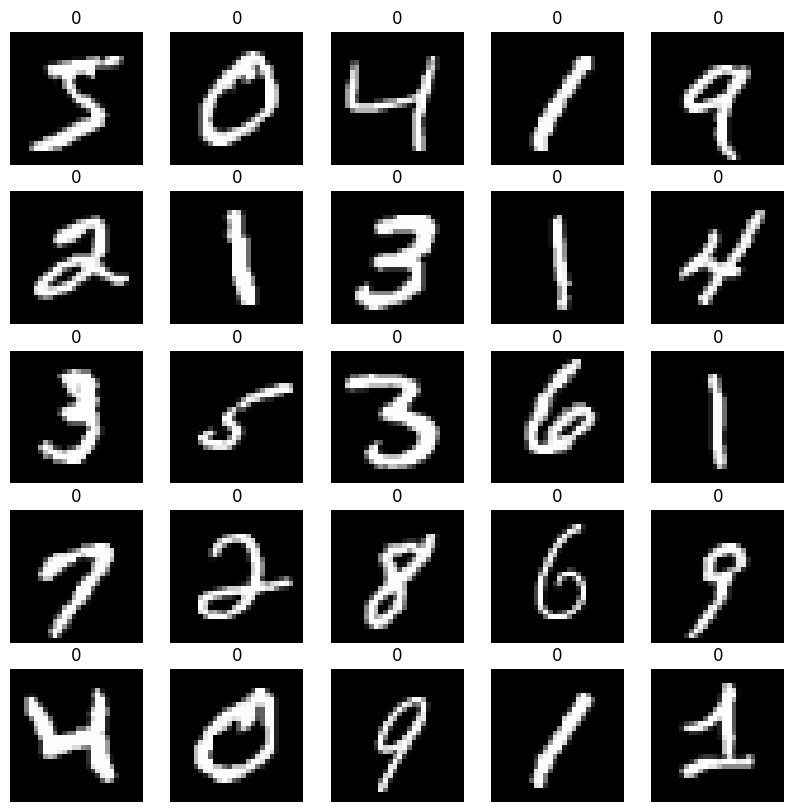

In [12]:
# Plot some samples from MNIST
plt.figure(figsize=(10, 10))
for i in range(25):
    plt.subplot(5, 5, i+1)
    plt.imshow(train_images[i], cmap='gray')
    plt.title(str(np.argmax(train_labels[i])))
    plt.axis('off')

In [5]:
# Preprocess the data
train_images = train_images.astype('float32') / 255.0
test_images  =  test_images.astype('float32') / 255.0

In [6]:
train_images.shape

(60000, 28, 28)

In [40]:
 train_labels.shape = (len(train_labels),)

In [41]:
np.set_printoptions(edgeitems=10)

In [42]:
# One-hot encode the labels
train_labels = to_categorical(train_labels)
test_labels  = to_categorical(test_labels)


In [43]:
# Define the MLP model
model = Sequential()
model.add(Flatten(input_shape=(28, 28)))  # Flatten the 28x28 images

model.add(Dense(512, activation='relu'))
model.add(Dense(256, activation='relu'))
model.add(Dense(10,  activation='softmax'))  # 10 output units for 10 digits (0-9)

d:\Makesh\Working\AI\Python_Envs\gen_ai\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [44]:
# Compile the model 
model.compile(optimizer = 'sgd', 
              loss      = 'categorical_crossentropy', 
              metrics   = ['accuracy'])

In [45]:
print("X shape:", train_images.shape)

train_labels = np.squeeze(train_labels)
print("y shape:", train_labels.shape)
print("Model output shape:", model.output_shape)

X shape: (60000, 28, 28)
y shape: (60000, 10)
Model output shape: (None, 10)


In [46]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_3 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 535,818 (2.04 MB)

 Trainable params: 535,818 (2.04 MB)

 Non-trainable params: 0 (0.00 B)

In [24]:
# # Visualize the model architecture
# plot_model(model, to_file='model_plot.png', show_shapes=True, show_layer_names=True)
# plt.imshow(plt.imread('model_plot.png'))
# plt.axis('off')

In [47]:
# Train the model
history = model.fit(train_images, 
                    train_labels, 
                    epochs          = 10, 
                    batch_size      = 32, 
                    validation_split= 0.2)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.0987 - loss: nan - val_accuracy: 0.0995 - val_loss: nan
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.0985 - loss: nan - val_accuracy: 0.0995 - val_loss: nan
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.0985 - loss: nan - val_accuracy: 0.0995 - val_loss: nan
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.0985 - loss: nan - val_accuracy: 0.0995 - val_loss: nan
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.0985 - loss: nan - val_accuracy: 0.0995 - val_loss: nan
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.0985 - loss: nan - val_accuracy: 0.0995 - val_loss: nan
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.0985 - loss: nan - val_accuracy: 0.0995 - val_loss: nan
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.0985 - loss: nan - val_accuracy: 0.0995 - val_loss: nan
Epoch 9/

In [48]:
# Evaluate the model
test_loss, test_acc = model.evaluate(test_images, test_labels)
print('Test accuracy:', test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 989us/step - accuracy: 0.0980 - loss: nan
Test accuracy: 0.09799999743700027


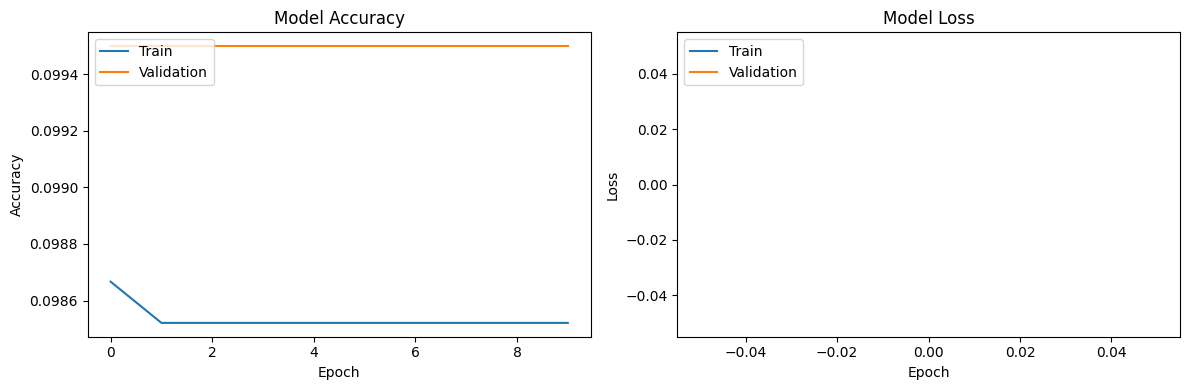

In [49]:
# Plot training & validation accuracy
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()